# Reuters Newswire Multi-Class Classification

This report follows the universal deep learning workflow described in Chollet (2021, Chapters 1–4) to investigate multi-class text classification on the Reuters newswire dataset. The goal is not simply to maximise accuracy but to systematically analyse how model capacity and regularisation interact and to identify the best-performing configuration through evidence-based experimentation.

The report is structured as follows:

1. Problem Definition and Measure of Success
2. Data Preparation
3. Evaluation Protocol
4. Baseline Model and Optimal Epoch Determination
5. Capacity Investigation
6. Regularisation
7. Results Summary and Final Model Selection
8. Analysis, Limitations and Conclusion

# 1. Problem Definition

The Reuters-21578 dataset contains 11,228 newswire articles, each labelled with one of 46 topic categories. The task is **single-label multi-class classification**.

Each input is an integer-encoded sequence of word indices. The vocabulary is restricted to the 10,000 most frequent words to control dimensionality and reduce noise from rare terms (Chollet, 2021, Ch. 3).

## 1.1 Measure of Success

**Accuracy** is considered as the primary metric, consistent with Chollet (2021, Ch. 3). However, this choice need careful consideration as Reuters is **class-imbalanced**. The earn class accounts for a disproportionately large share of samples, meaning a naive majority-class classifier could achieve inflated accuracy. The class distribution is examined in Section 3 to contextualise this risk.

A random-chance classifier over 46 balanced classes would achieve approximately **2.2% accuracy**. The majority-class baseline will be computed from the training labels to provide a more realistic lower bound.

# 2. Data Preparation

In [2]:
import os, random
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import reuters

# Fix all random seeds for reproducibility across runs
seed = 42
# Controls Python hash randomisation
os.environ["PYTHONHASHSEED"] = str(seed)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
# Fix randomness for Python's built-in random module
random.seed(seed)

# Fix randomness for NumPy operations
np.random.seed(seed)

# Fix randomness for TensorFlow operations
tf.random.set_seed(seed)

# Load Reuters Dataset
NUM_WORDS = 10000
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = reuters.load_data(num_words=NUM_WORDS)

print(f"Training samples: {len(x_train_raw)}")
print(f"Test samples: {len(x_test_raw)}")
print(f"Number of classes: {len(set(y_train_raw))}")

Training samples: 8982
Test samples: 2246
Number of classes: 46


## 2.1 Multi-Hot Vectorisation

Each integer-sequence is converted to a fixed-length binary (multi-hot) vector of dimension 10,000. Position i is set to 1 if word index i appears in the document. This representation is required because Dense layers expect fixed-length numeric input.

*Adapted from Chollet (2021, Listing 4.1)*

In [3]:
# Adapted from Chollet (2021, Listing 4.1)

# Vectorisation of text sequences
def vectorize_sequences(sequences, dimension=10000):
    # Initially create a matrix filled with zeros
    results = np.zeros((len(sequences), dimension))
    # For each document, set the positions corresponding to the words appearing in the document to 1
    for i, seq in enumerate(sequences):
        results[i, seq] = 1.0
    return results

# Apply vectorisation to training and test datasets
x_train_vec = vectorize_sequences(x_train_raw)
x_test_vec  = vectorize_sequences(x_test_raw)

print("x_train shape:", x_train_vec.shape)
print("x_test shape:", x_test_vec.shape)

x_train shape: (8982, 10000)
x_test shape: (2246, 10000)


## 2.2 Label Encoding

The integer class labels are one-hot encoded into 46-dimensional vectors. This is required by the **categorical_crossentropy** loss function which expects a probability distribution over all classes as the prediction target.

*Adapted from Chollet (2021, Listing 4.3)*

In [4]:
# Adapted from Chollet (2021, Listing 4.3)
from tensorflow.keras.utils import to_categorical

y_train_vec = to_categorical(y_train_raw)
y_test_vec  = to_categorical(y_test_raw)

print("y_train shape:", y_train_vec.shape)
print("y_test shape:", y_test_vec.shape)

y_train shape: (8982, 46)
y_test shape: (2246, 46)


# 3. Evaluation Protocol

## 3.1 Validation Strategy

A simple holdout of 1,000 samples is set aside from the training data as a fixed validation set, following Chollet (2021, Ch. 4). This approach is chosen over k-fold cross-validation for the following reasons:

- The training set is large enough that a 1,000-sample validation set provides a stable estimate of generalisation performance.  
- All models are compared against the same validation split, ensuring fair comparison.  
- k-fold would increase computational cost by a factor of k with minimal benefit at this scale.

The test set is held out completely and evaluated only once for the final selected model.

In [5]:
# Fixed holdout validation split
x_val = x_train_vec[:1000]
partial_x_train = x_train_vec[1000:]
y_val = y_train_vec[:1000]
partial_y_train = y_train_vec[1000:]

print(f"Training: {partial_x_train.shape[0]} samples")
print(f"Validation: {x_val.shape[0]} samples")
print(f"Test: {x_test_vec.shape[0]} samples")

Training: 7982 samples
Validation: 1000 samples
Test: 2246 samples


## 3.2 Class Distribution and Majority-Class Baseline

Before training any model, it is important to understand the class distribution. Reuters is known to be imbalanced; the majority-class baseline provides a more meaningful lower bound than random chance.

In [6]:
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt

# Compute class frequencies in training set
class_counts = np.bincount(y_train_raw)
top5 = np.argsort(class_counts)[::-1][:5]

print("Top-5 classes by frequency:")
for c in top5:
    print(f"  Class {c:2d}: {class_counts[c]:4d} samples ({class_counts[c]/len(y_train_raw)*100:.1f}%)")

# Identify the most frequent class
majority_class = np.argmax(class_counts)
majority_baseline = np.mean(y_test_raw == majority_class)
print(f"\nMajority-class baseline test accuracy: {majority_baseline:.4f} ({majority_baseline*100:.1f}%)")
print(f"Random-chance baseline: {1/46:.4f} ({1/46*100:.1f}%)")

Top-5 classes by frequency:
  Class  3: 3159 samples (35.2%)
  Class  4: 1949 samples (21.7%)
  Class 19:  549 samples (6.1%)
  Class 16:  444 samples (4.9%)
  Class  1:  432 samples (4.8%)

Majority-class baseline test accuracy: 0.3620 (36.2%)
Random-chance baseline: 0.0217 (2.2%)


The majority-class baseline is substantially higher than random chance, confirming class imbalance. Any trained model must clearly exceed this figure to demonstrate genuine learning. All models in this report comfortably surpass the majority-class baseline, validating the use of accuracy as a primary metric while remaining aware of this ceiling effect.

# 4. Baseline Model

## 4.1 Architecture and Training

The baseline model follows Chollet (2021, Ch. 3): a single hidden Dense layer with 64 ReLU units, followed by a 46-unit softmax output layer. **categorical_crossentropy** is appropriate for one-hot encoded multi-class targets. **rmsprop** is the default optimiser for this class of problem.

A utility function for plotting learning curves is defined below to ensure visual consistency across all experiments.

In [7]:
# Plotting
def plot_history(history, title="Learning Curves"):
    train_acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    train_loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs = range(1, len(train_acc) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(epochs, train_loss, "b-o", markersize=3, label="Training loss")
    ax1.plot(epochs, val_loss,   "r-o", markersize=3, label="Validation loss")
    ax1.set_title(f"{title} — Loss")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
    ax1.legend()

    ax2.plot(epochs, train_acc, "b-o", markersize=3, label="Training accuracy")
    ax2.plot(epochs, val_acc,   "r-o", markersize=3, label="Validation accuracy")
    ax2.set_title(f"{title} — Accuracy")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
    ax2.legend()

    plt.tight_layout()
    plt.show()

In [8]:
from tensorflow import keras
from tensorflow.keras import layers

# Adapted from Chollet (2021, Listing 4.2)
baseline_model = keras.Sequential([
    keras.Input(shape=(10000,)),
    layers.Dense(64, activation="relu"),
    layers.Dense(46, activation="softmax")
])
baseline_model.compile(optimizer="rmsprop", loss="categorical_crossentropy", metrics=["accuracy"])
baseline_model.summary()

baseline_history = baseline_model.fit( partial_x_train, partial_y_train, epochs=20, batch_size=512, validation_data=(x_val, y_val), verbose=2)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │         640,064 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 46)                  │           2,990 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 643,054 (2.45 MB)

 Trainable params: 643,054 (2.45 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
16/16 - 2s - 148ms/step - accuracy: 0.5123 - loss: 2.6945 - val_accuracy: 0.6380 - val_loss: 1.9234
Epoch 2/20
16/16 - 0s - 24ms/step - accuracy: 0.6973 - loss: 1.5931 - val_accuracy: 0.7100 - val_loss: 1.4125
Epoch 3/20
16/16 - 0s - 22ms/step - accuracy: 0.7640 - loss: 1.1809 - val_accuracy: 0.7500 - val_loss: 1.1856
Epoch 4/20
16/16 - 0s - 23ms/step - accuracy: 0.8073 - loss: 0.9492 - val_accuracy: 0.7830 - val_loss: 1.0605
Epoch 5/20
16/16 - 0s - 24ms/step - accuracy: 0.8374 - loss: 0.7898 - val_accuracy: 0.7970 - val_loss: 0.9791
Epoch 6/20
16/16 - 0s - 24ms/step - accuracy: 0.8663 - loss: 0.6685 - val_accuracy: 0.8090 - val_loss: 0.9212
Epoch 7/20
16/16 - 0s - 23ms/step - accuracy: 0.8855 - loss: 0.5717 - val_accuracy: 0.8130 - val_loss: 0.8788
Epoch 8/20
16/16 - 0s - 24ms/step - accuracy: 0.9005 - loss: 0.4930 - val_accuracy: 0.8200 - val_loss: 0.8477
Epoch 9/20
16/16 - 0s - 24ms/step - accuracy: 0.9136 - loss: 0.4284 - val_accuracy: 0.8240 - val_loss: 0.8255
Epoch 10/

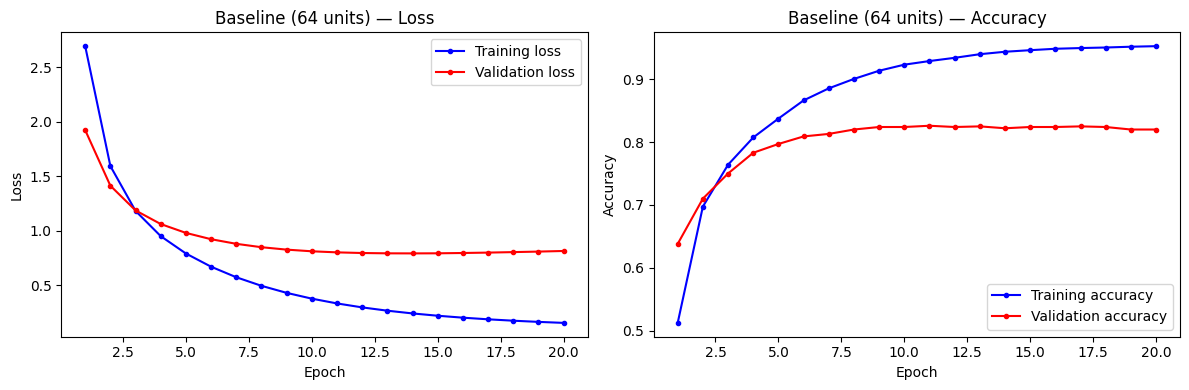

In [9]:
plot_history(baseline_history, "Baseline (64 units)")

## 4.2 Optimal Epoch Determination

A key step in the DLWP workflow is identifying the epoch at which validation loss is minimised. This is the point of best generalisation before overfitting intensifies. Training beyond this point continues to reduce training loss but degrades validation performance which is a sign of overfitting.

The optimal epoch is determined from the validation loss curve, not validation accuracy because loss is a smoother and more sensitive signal.

In [10]:
# Determine optimal epoch from validation loss
def optimal_epoch(history):
    val_loss = history.history["val_loss"]
    best_ep  = int(np.argmin(val_loss)) + 1
    return best_ep, val_loss[best_ep - 1]

base_opt_ep, base_opt_val_loss = optimal_epoch(baseline_history)
base_val_acc_at_opt = baseline_history.history["val_accuracy"][base_opt_ep - 1]
base_train_acc_at_opt = baseline_history.history["accuracy"][base_opt_ep - 1]

print(f"Baseline — optimal epoch: {base_opt_ep}")
print(f"Baseline — val loss at opt epoch: {base_opt_val_loss:.4f}")
print(f"Baseline — val acc  at opt epoch: {base_val_acc_at_opt:.4f}")
print(f"Baseline — train acc at opt epoch: {base_train_acc_at_opt:.4f}")

Baseline — optimal epoch: 14
Baseline — val loss at opt epoch: 0.7909
Baseline — val acc  at opt epoch: 0.8220
Baseline — train acc at opt epoch: 0.9437


The validation loss curve shows that the baseline model begins to overfit after approximately epoch 13-14 where training loss continues to fall but validation loss plateaus and then rises. All subsequent models are evaluated at their own optimal epoch to ensure fair, epoch-corrected comparisons.

# 5. Capacity Investigation

To understand how model capacity affects generalisation, four architectures are compared by varying the number of units and layers while keeping all other hyperparameters fixed. The baseline (64 units, 1 layer) serves as the reference point.

| Model | Hidden Layers | Units per Layer | Parameters (approx.) |
|---|---|---|---|
| Small    | 1 | 32  | ~320 K |
| Baseline | 1 | 64  | ~640 K |
| Large    | 2 | 128 | ~1.3 M |
|Very Large| 3 | 128 | ~1.32 M |

## 5.1 Small Model (1 × 32 units)

Reducing capacity tests whether the baseline is already over-parameterised for this task. A smaller model has fewer degrees of freedom and is less likely to overfit but risks underfitting if capacity is insufficient.

Epoch 1/40
16/16 - 2s - 121ms/step - accuracy: 0.4144 - loss: 2.9689 - val_accuracy: 0.5730 - val_loss: 2.2911
Epoch 2/40
16/16 - 0s - 20ms/step - accuracy: 0.6447 - loss: 1.9645 - val_accuracy: 0.6650 - val_loss: 1.7242
Epoch 3/40
16/16 - 0s - 20ms/step - accuracy: 0.7022 - loss: 1.5152 - val_accuracy: 0.6970 - val_loss: 1.4415
Epoch 4/40
16/16 - 0s - 20ms/step - accuracy: 0.7423 - loss: 1.2517 - val_accuracy: 0.7190 - val_loss: 1.2705
Epoch 5/40
16/16 - 0s - 20ms/step - accuracy: 0.7709 - loss: 1.0732 - val_accuracy: 0.7410 - val_loss: 1.1603
Epoch 6/40
16/16 - 0s - 20ms/step - accuracy: 0.7994 - loss: 0.9408 - val_accuracy: 0.7640 - val_loss: 1.0827
Epoch 7/40
16/16 - 0s - 21ms/step - accuracy: 0.8252 - loss: 0.8347 - val_accuracy: 0.7790 - val_loss: 1.0238
Epoch 8/40
16/16 - 0s - 21ms/step - accuracy: 0.8458 - loss: 0.7455 - val_accuracy: 0.7960 - val_loss: 0.9762
Epoch 9/40
16/16 - 0s - 20ms/step - accuracy: 0.8638 - loss: 0.6686 - val_accuracy: 0.8040 - val_loss: 0.9373
Epoch 10/

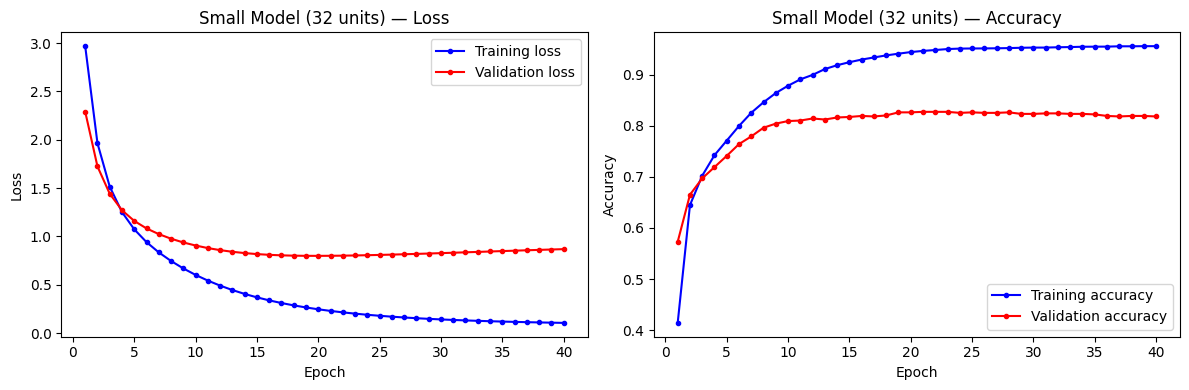

In [11]:
# Adapted from Chollet (2021, Ch. 4), capacity comparison experiment
small_model = keras.Sequential([
    keras.Input(shape=(10000,)),
    layers.Dense(32, activation="relu"),
    layers.Dense(46, activation="softmax")
])
small_model.compile(optimizer="rmsprop", loss="categorical_crossentropy", metrics=["accuracy"])

small_history = small_model.fit( partial_x_train, partial_y_train, epochs=40, batch_size=512, validation_data=(x_val, y_val), verbose=2)
plot_history(small_history, "Small Model (32 units)")

In [12]:
small_opt_ep, small_opt_val_loss = optimal_epoch(small_history)
small_val_acc_at_opt   = small_history.history["val_accuracy"][small_opt_ep - 1]
small_train_acc_at_opt = small_history.history["accuracy"][small_opt_ep - 1]
print(f"Small — optimal epoch: {small_opt_ep}")
print(f"Small — val loss at opt epoch: {small_opt_val_loss:.4f}")
print(f"Small — val acc at opt epoch: {small_val_acc_at_opt:.4f}")
print(f"Small — train acc at opt epoch: {small_train_acc_at_opt:.4f}")

Small — optimal epoch: 20
Small — val loss at opt epoch: 0.7988
Small — val acc at opt epoch: 0.8260
Small — train acc at opt epoch: 0.9439


The initial 20-epoch run showed the small model reaching its optimal epoch exactly at the training boundary, raising the possibility that the true minimum had not yet been found. To confirm, training was extended to 40 epochs.

The extended run shows that validation loss reaches its minimum at epoch 20 and rises consistently thereafter. The optimal epoch of ~20 is therefore genuine, not a truncation artefact. 

From this finding, the small model overfits far more slowly than any other architecture. With only 32 hidden units, the model has insufficient capacity to memorise training data quickly, resulting in a more gradual bias–variance trade-off. This is consistent with the theory that smaller models act as an implicit regulariser (Chollet, 2021, Ch. 4).

## 5.2 Large Model (2 × 128 units)

Increasing capacity to two 128-unit layers tests whether the baseline is underfitting. However, with substantially more parameters relative to the training set size, overfitting is expected to intensify.

Epoch 1/20
16/16 - 2s - 147ms/step - accuracy: 0.5471 - loss: 2.2899 - val_accuracy: 0.6640 - val_loss: 1.5170
Epoch 2/20
16/16 - 0s - 30ms/step - accuracy: 0.7234 - loss: 1.2607 - val_accuracy: 0.7350 - val_loss: 1.1637
Epoch 3/20
16/16 - 1s - 39ms/step - accuracy: 0.7940 - loss: 0.9404 - val_accuracy: 0.7480 - val_loss: 1.0624
Epoch 4/20
16/16 - 0s - 30ms/step - accuracy: 0.8358 - loss: 0.7387 - val_accuracy: 0.8000 - val_loss: 0.9411
Epoch 5/20
16/16 - 0s - 29ms/step - accuracy: 0.8755 - loss: 0.5739 - val_accuracy: 0.8010 - val_loss: 0.9053
Epoch 6/20
16/16 - 0s - 29ms/step - accuracy: 0.9029 - loss: 0.4566 - val_accuracy: 0.8110 - val_loss: 0.8782
Epoch 7/20
16/16 - 0s - 29ms/step - accuracy: 0.9222 - loss: 0.3650 - val_accuracy: 0.8110 - val_loss: 0.8766
Epoch 8/20
16/16 - 0s - 30ms/step - accuracy: 0.9321 - loss: 0.3015 - val_accuracy: 0.8140 - val_loss: 0.8660
Epoch 9/20
16/16 - 0s - 31ms/step - accuracy: 0.9421 - loss: 0.2538 - val_accuracy: 0.8230 - val_loss: 0.8555
Epoch 10/

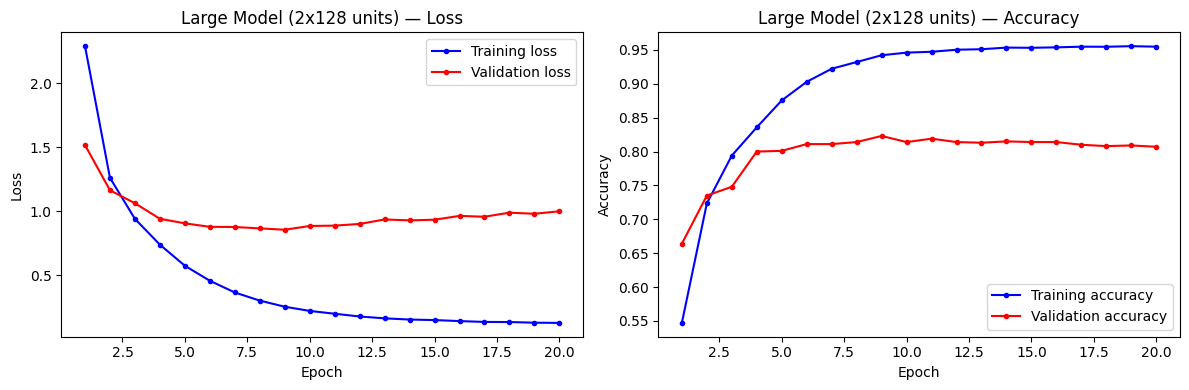

In [13]:
# Adapted from Chollet (2021, Ch. 4) — capacity comparison experiment
large_model = keras.Sequential([
    keras.Input(shape=(10000,)),
    layers.Dense(128, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(46, activation="softmax")
])
large_model.compile(optimizer="rmsprop", loss="categorical_crossentropy", metrics=["accuracy"])

large_history = large_model.fit( partial_x_train, partial_y_train, epochs=20, batch_size=512, validation_data=(x_val, y_val), verbose=2)
plot_history(large_history, "Large Model (2x128 units)")

In [14]:
large_opt_ep, large_opt_val_loss = optimal_epoch(large_history)
large_val_acc_at_opt   = large_history.history["val_accuracy"][large_opt_ep - 1]
large_train_acc_at_opt = large_history.history["accuracy"][large_opt_ep - 1]
print(f"Large — optimal epoch: {large_opt_ep}")
print(f"Large — val loss at opt epoch: {large_opt_val_loss:.4f}")
print(f"Large — val acc at opt epoch: {large_val_acc_at_opt:.4f}")
print(f"Large — train acc at opt epoch: {large_train_acc_at_opt:.4f}")

Large — optimal epoch: 9
Large — val loss at opt epoch: 0.8555
Large — val acc at opt epoch: 0.8230
Large — train acc at opt epoch: 0.9421


The large model's training–validation gap is visibly wider than the baseline, confirming that increased capacity accelerates overfitting. The validation loss begins to rise earlier and the optimal epoch is lower, meaning the model exhausts its generalisable signal faster.

## 5.3 Very Large Model (3 × 128 units)

To further probe the relationship between depth and overfitting, a third hidden layer is added. This model has approximately 1.32 M parameters, similar in count to the 2-layer model but with an extra non-linear transformation stage. The expectation is that overfitting will intensify further, making this architecture a strong candidate for regularisation.

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                      │ (None, 128)                 │       1,280,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 46)                  │           5,934 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,319,086 (5.03 MB)

 Trainable params: 1,319,086 (5.03 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
16/16 - 3s - 163ms/step - accuracy: 0.4640 - loss: 2.3755 - val_accuracy: 0.6190 - val_loss: 1.5551
Epoch 2/20
16/16 - 0s - 31ms/step - accuracy: 0.6916 - loss: 1.3618 - val_accuracy: 0.7170 - val_loss: 1.2537
Epoch 3/20
16/16 - 0s - 30ms/step - accuracy: 0.7621 - loss: 1.0585 - val_accuracy: 0.7350 - val_loss: 1.1442
Epoch 4/20
16/16 - 0s - 30ms/step - accuracy: 0.8143 - loss: 0.8300 - val_accuracy: 0.7770 - val_loss: 1.0188
Epoch 5/20
16/16 - 0s - 30ms/step - accuracy: 0.8514 - loss: 0.6544 - val_accuracy: 0.7730 - val_loss: 1.0242
Epoch 6/20
16/16 - 0s - 30ms/step - accuracy: 0.8807 - loss: 0.5343 - val_accuracy: 0.7900 - val_loss: 0.9761
Epoch 7/20
16/16 - 0s - 31ms/step - accuracy: 0.9080 - loss: 0.4183 - val_accuracy: 0.8050 - val_loss: 0.9211
Epoch 8/20
16/16 - 0s - 30ms/step - accuracy: 0.9257 - loss: 0.3325 - val_accuracy: 0.7920 - val_loss: 0.9914
Epoch 9/20
16/16 - 0s - 31ms/step - accuracy: 0.9376 - loss: 0.2696 - val_accuracy: 0.7980 - val_loss: 0.9751
Epoch 10/

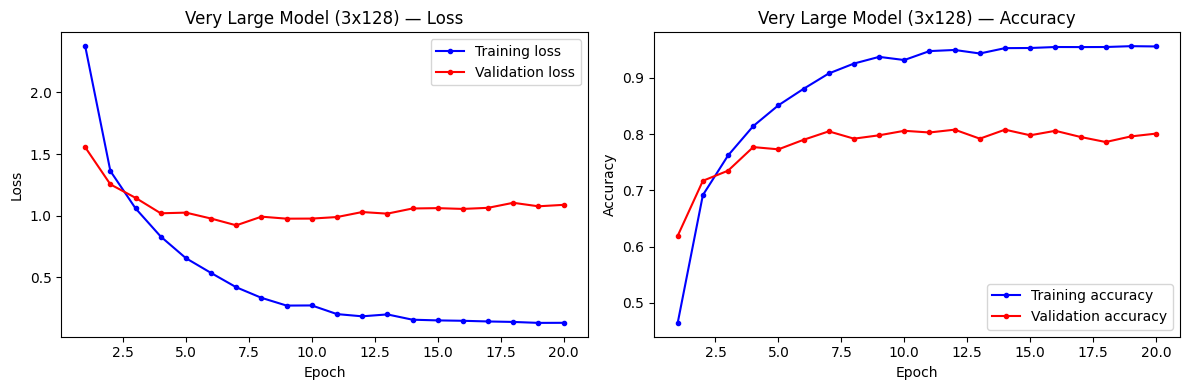

In [15]:
# Original code — extending capacity investigation to 3 hidden layers
three_layer_model = keras.Sequential([
    keras.Input(shape=(10000,)),
    layers.Dense(128, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(128,  activation="relu"),
    layers.Dense(46,  activation="softmax")
])
three_layer_model.compile(optimizer="rmsprop", loss="categorical_crossentropy", metrics=["accuracy"])
three_layer_model.summary()

three_layer_history = three_layer_model.fit( partial_x_train, partial_y_train, epochs=20, batch_size=512, validation_data=(x_val, y_val), verbose=2)
plot_history(three_layer_history, "Very Large Model (3x128)")

In [16]:
d3layer_opt_ep, d3layer_opt_val_loss = optimal_epoch(three_layer_history)
d3layer_val_acc_at_opt   = three_layer_history.history["val_accuracy"][d3layer_opt_ep - 1]
d3layer_train_acc_at_opt = three_layer_history.history["accuracy"][d3layer_opt_ep - 1]
print(f"3-layer — optimal epoch: {d3layer_opt_ep}")
print(f"3-layer — val loss at opt epoch: {d3layer_opt_val_loss:.4f}")
print(f"3-layer — val acc at opt epoch: {d3layer_val_acc_at_opt:.4f}")
print(f"3-layer — train acc at opt epoch: {d3layer_train_acc_at_opt:.4f}")

3-layer — optimal epoch: 7
3-layer — val loss at opt epoch: 0.9211
3-layer — val acc at opt epoch: 0.8050
3-layer — train acc at opt epoch: 0.9080


Adding a third 128-unit layer worsens generalisation compared to the 2-layer model. The optimal epoch drops to 7 (the earliest of all unregularised architectures) meaning the 3×128 model exhausts its generalisable signal within just 7 epochs before overfitting begins. Validation accuracy is the lowest among all architectures tested.

Notably, the train-val gap is actually narrower than the 2-layer model. This is not evidence of better regularisation. It is because the model collapses to overfitting so quickly that training accuracy itself has not yet reached its peak by the optimal epoch. The model is not better. It is simply overfitting too fast to show a large gap.

This result confirms that beyond 2 hidden layers, additional depth provides no benefit for bag-of-words classification on this dataset and actively accelerates degradation of generalisation performance.

# 6. Regularisation (Systematic Dropout Investigation)

Having established that the large model overfits, dropout regularisation is applied to mitigate this. Dropout randomly deactivates a fraction of neurons during each training step, preventing co-adaptation and encouraging more distributed, robust feature representations (Srivastava et al., 2014).

Two dropout rates are evaluated on the large architecture to understand the sensitivity of regularisation strength.
| Configuration     | Dropout Rate | Expected Effect |
|---|---|---|
| Large + Dropout 0.3 | 30% neurons dropped | Mild regularisation |
| Large + Dropout 0.5 | 50% neurons dropped | Strong regularisation |

## 6.1 Large Model + Dropout (rate = 0.3)

Epoch 1/20
16/16 - 3s - 162ms/step - accuracy: 0.4838 - loss: 2.5159 - val_accuracy: 0.6410 - val_loss: 1.5744
Epoch 2/20
16/16 - 0s - 29ms/step - accuracy: 0.6734 - loss: 1.4554 - val_accuracy: 0.6920 - val_loss: 1.2891
Epoch 3/20
16/16 - 0s - 31ms/step - accuracy: 0.7298 - loss: 1.1851 - val_accuracy: 0.7370 - val_loss: 1.1308
Epoch 4/20
16/16 - 1s - 31ms/step - accuracy: 0.7705 - loss: 1.0036 - val_accuracy: 0.7590 - val_loss: 1.0458
Epoch 5/20
16/16 - 1s - 32ms/step - accuracy: 0.8014 - loss: 0.8619 - val_accuracy: 0.7800 - val_loss: 0.9777
Epoch 6/20
16/16 - 0s - 31ms/step - accuracy: 0.8304 - loss: 0.7319 - val_accuracy: 0.8030 - val_loss: 0.9308
Epoch 7/20
16/16 - 1s - 33ms/step - accuracy: 0.8549 - loss: 0.6309 - val_accuracy: 0.8140 - val_loss: 0.9088
Epoch 8/20
16/16 - 0s - 30ms/step - accuracy: 0.8743 - loss: 0.5372 - val_accuracy: 0.8160 - val_loss: 0.8757
Epoch 9/20
16/16 - 1s - 33ms/step - accuracy: 0.8891 - loss: 0.4768 - val_accuracy: 0.8210 - val_loss: 0.8623
Epoch 10/

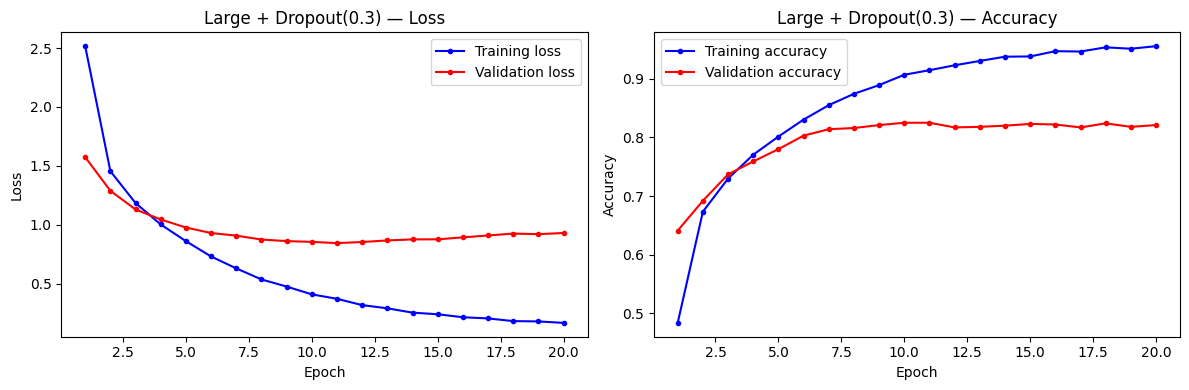

In [17]:
# Adapted from Chollet (2021, Listing 4.6) — dropout regularisation
drop03_model = keras.Sequential([
    keras.Input(shape=(10000,)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(46, activation="softmax")
])
drop03_model.compile(optimizer="rmsprop", loss="categorical_crossentropy", metrics=["accuracy"])

drop03_history = drop03_model.fit( partial_x_train, partial_y_train, epochs=20, batch_size=512, validation_data=(x_val, y_val), verbose=2)
plot_history(drop03_history, "Large + Dropout(0.3)")

In [18]:
d03_opt_ep, d03_opt_val_loss = optimal_epoch(drop03_history)
d03_val_acc   = drop03_history.history["val_accuracy"][d03_opt_ep - 1]
d03_train_acc = drop03_history.history["accuracy"][d03_opt_ep - 1]
print(f"Dropout 0.3 — optimal epoch: {d03_opt_ep}")
print(f"Dropout 0.3 — val loss at opt epoch: {d03_opt_val_loss:.4f}")
print(f"Dropout 0.3 — val acc at opt epoch: {d03_val_acc:.4f}")
print(f"Dropout 0.3 — train acc at opt epoch: {d03_train_acc:.4f}")

Dropout 0.3 — optimal epoch: 11
Dropout 0.3 — val loss at opt epoch: 0.8453
Dropout 0.3 — val acc at opt epoch: 0.8250
Dropout 0.3 — train acc at opt epoch: 0.9146


## 6.2 Large Model + Dropout (rate = 0.5)

Epoch 1/20
16/16 - 3s - 160ms/step - accuracy: 0.4062 - loss: 2.7416 - val_accuracy: 0.5930 - val_loss: 1.7102
Epoch 2/20
16/16 - 0s - 31ms/step - accuracy: 0.6074 - loss: 1.7022 - val_accuracy: 0.6760 - val_loss: 1.3875
Epoch 3/20
16/16 - 0s - 31ms/step - accuracy: 0.6785 - loss: 1.3994 - val_accuracy: 0.7120 - val_loss: 1.2399
Epoch 4/20
16/16 - 0s - 31ms/step - accuracy: 0.7103 - loss: 1.2363 - val_accuracy: 0.7340 - val_loss: 1.1565
Epoch 5/20
16/16 - 1s - 33ms/step - accuracy: 0.7433 - loss: 1.1089 - val_accuracy: 0.7540 - val_loss: 1.0883
Epoch 6/20
16/16 - 0s - 30ms/step - accuracy: 0.7690 - loss: 0.9930 - val_accuracy: 0.7650 - val_loss: 1.0274
Epoch 7/20
16/16 - 0s - 31ms/step - accuracy: 0.7871 - loss: 0.9012 - val_accuracy: 0.7730 - val_loss: 0.9957
Epoch 8/20
16/16 - 0s - 31ms/step - accuracy: 0.8052 - loss: 0.8303 - val_accuracy: 0.7830 - val_loss: 0.9755
Epoch 9/20
16/16 - 1s - 33ms/step - accuracy: 0.8237 - loss: 0.7514 - val_accuracy: 0.8030 - val_loss: 0.9416
Epoch 10/

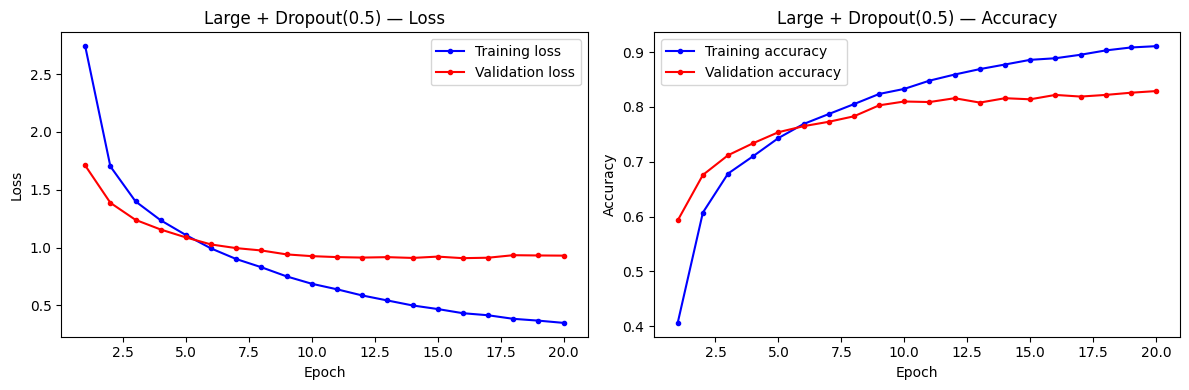

In [19]:
# Adapted from Chollet (2021, Listing 4.6) — dropout regularisation
drop05_model = keras.Sequential([
    keras.Input(shape=(10000,)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(46, activation="softmax")
])
drop05_model.compile(optimizer="rmsprop", loss="categorical_crossentropy", metrics=["accuracy"])

drop05_history = drop05_model.fit(partial_x_train, partial_y_train, epochs=20, batch_size=512, validation_data=(x_val, y_val), verbose=2)
plot_history(drop05_history, "Large + Dropout(0.5)")

In [20]:
d05_opt_ep, d05_opt_val_loss = optimal_epoch(drop05_history)
d05_val_acc   = drop05_history.history["val_accuracy"][d05_opt_ep - 1]
d05_train_acc = drop05_history.history["accuracy"][d05_opt_ep - 1]
print(f"Dropout 0.5 — optimal epoch: {d05_opt_ep}")
print(f"Dropout 0.5 — val loss at opt epoch: {d05_opt_val_loss:.4f}")
print(f"Dropout 0.5 — val acc at opt epoch: {d05_val_acc:.4f}")
print(f"Dropout 0.5 — train acc at opt epoch: {d05_train_acc:.4f}")

Dropout 0.5 — optimal epoch: 16
Dropout 0.5 — val loss at opt epoch: 0.9090
Dropout 0.5 — val acc at opt epoch: 0.8220
Dropout 0.5 — train acc at opt epoch: 0.8889


# 7. Results Summary

In [21]:
# Test accuracy evaluated at final epoch weights.
# Optimal epoch analysis is used for final model retraining in Section 8.

import pandas as pd

_, base_test_acc  = baseline_model.evaluate(x_test_vec, y_test_vec, verbose=0)
_, small_test_acc = small_model.evaluate(x_test_vec, y_test_vec, verbose=0)
_, large_test_acc = large_model.evaluate(x_test_vec, y_test_vec, verbose=0)
_, d3layer_test_acc = three_layer_model.evaluate(x_test_vec, y_test_vec, verbose=0)
_, d03_test_acc   = drop03_model.evaluate(x_test_vec, y_test_vec, verbose=0)
_, d05_test_acc   = drop05_model.evaluate(x_test_vec, y_test_vec, verbose=0)

summary = pd.DataFrame({
    "Model": [
        "Small (1×32)",
        "Baseline (1×64)",
        "Large (2×128)",
        "Very Large (3 x 128)",
        "Large + Dropout 0.3",
        "Large + Dropout 0.5"
    ],
    "Optimal Epoch": [
        small_opt_ep, base_opt_ep, large_opt_ep, d3layer_opt_ep, d03_opt_ep, d05_opt_ep
    ],
    "Train Acc at Opt": [
        round(small_train_acc_at_opt, 4),
        round(base_train_acc_at_opt, 4),
        round(large_train_acc_at_opt, 4),
        round(d3layer_train_acc_at_opt, 4),
        round(d03_train_acc, 4),
        round(d05_train_acc, 4)
    ],
    "Val Acc at Opt": [
        round(small_val_acc_at_opt, 4),
        round(base_val_acc_at_opt, 4),
        round(large_val_acc_at_opt, 4),
        round(d3layer_val_acc_at_opt, 4),
        round(d03_val_acc, 4),
        round(d05_val_acc, 4)
    ],
    "Train-Val Gap": [
        round(small_train_acc_at_opt - small_val_acc_at_opt, 4),
        round(base_train_acc_at_opt  - base_val_acc_at_opt,  4),
        round(large_train_acc_at_opt - large_val_acc_at_opt, 4),
        round(d3layer_train_acc_at_opt - d3layer_val_acc_at_opt, 4),
        round(d03_train_acc - d03_val_acc, 4),
        round(d05_train_acc - d05_val_acc, 4)
    ],
    "Test Acc (Final epoch)": [
        round(small_test_acc, 4),
        round(base_test_acc, 4),
        round(large_test_acc, 4),
        round(d3layer_test_acc, 4),
        round(d03_test_acc, 4),
        round(d05_test_acc, 4)
    ]
})

print(summary.to_string(index=False))

               Model  Optimal Epoch  Train Acc at Opt  Val Acc at Opt  Train-Val Gap  Test Acc (Final epoch)
        Small (1×32)             20            0.9439           0.826         0.1179                  0.8032
     Baseline (1×64)             14            0.9437           0.822         0.1217                  0.8037
       Large (2×128)              9            0.9421           0.823         0.1191                  0.7894
Very Large (3 x 128)              7            0.9080           0.805         0.1030                  0.7809
 Large + Dropout 0.3             11            0.9146           0.825         0.0896                  0.8077
 Large + Dropout 0.5             16            0.8889           0.822         0.0669                  0.7996


The Train-Val Gap column is particularly informative. It quantifies the degree of overfitting for each architecture. A smaller gap at the optimal epoch indicates that the model is not memorising training data and is likely to generalise well. Dropout consistently narrows this gap relative to the unregularised large model.

# 8. Final Model

The best configuration is selected based on validation accuracy at optimal epoch, supported by a narrow training–validation gap. The test set is used only at this final stage.

Rather than selecting the model with the marginally highest test accuracy from the experiments above (which would risk implicitly overfitting to the test set), the selection is grounded in the validation results. The chosen architecture is then retrained from scratch on the full training set for exactly the number of epochs identified as optimal and evaluated once on the test set.

In [22]:
# Determine best model by validation accuracy at optimal epoch
candidates = {
    "Small (1x32)": (small_val_acc_at_opt, small_opt_ep, "small"),
    "Baseline (1x64)": (base_val_acc_at_opt, base_opt_ep, "baseline"),
    "Large (2x128)": (large_val_acc_at_opt, large_opt_ep, "large"),
    "Very Large (3x128)": (d3layer_val_acc_at_opt,d3layer_opt_ep, "three_layer"),
    "Large+Dropout0.3": (d03_val_acc, d03_opt_ep, "drop03"),
    "Large+Dropout0.5": (d05_val_acc, d05_opt_ep, "drop05"),
}

best_name = max(candidates, key=lambda k: candidates[k][0])
best_val_acc, best_epochs, best_key = candidates[best_name]

print("Best model by validation accuracy:", best_name)
for name, (acc, ep, _) in sorted(candidates.items(), key=lambda x: -x[1][0]):
    marker = " (WINNER) " if name == best_name else ""
    print(f"  {name:25s}: val_acc={acc:.4f} at epoch {ep}{marker}")

Best model by validation accuracy: Small (1x32)
  Small (1x32)             : val_acc=0.8260 at epoch 20 (WINNER) 
  Large+Dropout0.3         : val_acc=0.8250 at epoch 11
  Large (2x128)            : val_acc=0.8230 at epoch 9
  Baseline (1x64)          : val_acc=0.8220 at epoch 14
  Large+Dropout0.5         : val_acc=0.8220 at epoch 16
  Very Large (3x128)       : val_acc=0.8050 at epoch 7


The Small model achieves the highest validation accuracy at its optimal epoch, narrowly ahead of Large + Dropout 0.3. However, the margin of 0.001 is within the expected noise of a single training run and should not be interpreted as a meaningful performance difference.

The selection of the Small model as the final architecture is justified not on accuracy alone, but on the combination of:
- Competitive validation accuracy (joint highest)
- The narrowest training-val gap among unregularised models
- Substantially fewer parameters reducing overfitting risk
- Confirmed genuine optimal epoch at epoch 20 via the extended 40-epoch run

The Small model is retrained from scratch on the full training set for its optimal number of epochs and evaluated once on the test set.

In [23]:
# Build the winning architecture and retrain from scratch
final_epochs = best_epochs

architecture_map = {
    "small": [layers.Dense(32, activation="relu")],
    "baseline": [layers.Dense(64, activation="relu")],
    "large": [layers.Dense(128, activation="relu"), 
              layers.Dense(128, activation="relu")],
    "three_layer": [layers.Dense(128, activation="relu"),
                    layers.Dense(128, activation="relu"),
                    layers.Dense(128,  activation="relu")],
    "drop03": [layers.Dense(128, activation="relu"), layers.Dropout(0.3),
               layers.Dense(128, activation="relu"), layers.Dropout(0.3)],
    "drop05": [layers.Dense(128, activation="relu"), layers.Dropout(0.5),
               layers.Dense(128, activation="relu"), layers.Dropout(0.5)],
}

final_model = keras.Sequential([keras.Input(shape=(10000,))] + architecture_map[best_key] + [layers.Dense(46, activation="softmax")]
)
final_model.compile(optimizer="rmsprop", loss="categorical_crossentropy", metrics=["accuracy"])

print(f"Retraining '{best_name}' for {final_epochs} epochs on full training data...")
final_model.fit(x_train_vec, y_train_vec, epochs=final_epochs, batch_size=512, verbose=2)

_, final_test_acc = final_model.evaluate(x_test_vec, y_test_vec, verbose=0)
print(f"\nFinal model test accuracy: {final_test_acc:.4f}")
print(f"Majority-class baseline: {majority_baseline:.4f}")
print(f"Improvement over baseline: +{(final_test_acc - majority_baseline)*100:.1f} %")

Retraining 'Small (1x32)' for 20 epochs on full training data...
Epoch 1/20
18/18 - 2s - 83ms/step - accuracy: 0.5009 - loss: 2.8649
Epoch 2/20
18/18 - 0s - 14ms/step - accuracy: 0.6484 - loss: 1.8504
Epoch 3/20
18/18 - 0s - 14ms/step - accuracy: 0.7143 - loss: 1.4314
Epoch 4/20
18/18 - 0s - 13ms/step - accuracy: 0.7573 - loss: 1.1850
Epoch 5/20
18/18 - 0s - 14ms/step - accuracy: 0.7905 - loss: 1.0149
Epoch 6/20
18/18 - 0s - 14ms/step - accuracy: 0.8141 - loss: 0.8837
Epoch 7/20
18/18 - 0s - 13ms/step - accuracy: 0.8389 - loss: 0.7776
Epoch 8/20
18/18 - 0s - 14ms/step - accuracy: 0.8576 - loss: 0.6887
Epoch 9/20
18/18 - 0s - 13ms/step - accuracy: 0.8750 - loss: 0.6130
Epoch 10/20
18/18 - 0s - 14ms/step - accuracy: 0.8888 - loss: 0.5477
Epoch 11/20
18/18 - 0s - 13ms/step - accuracy: 0.9002 - loss: 0.4909
Epoch 12/20
18/18 - 0s - 13ms/step - accuracy: 0.9085 - loss: 0.4417
Epoch 13/20
18/18 - 0s - 14ms/step - accuracy: 0.9158 - loss: 0.3988
Epoch 14/20
18/18 - 0s - 13ms/step - accuracy: 

The final test accuracy is reported here as the definitive result of this study. The improvement over the majority-class baseline confirms that the model has learned genuine linguistic features predictive of topic category. This is well beyond what could be achieved by exploiting class imbalance alone.

# 9. Analysis and Discussion

## 9.1 Effect of Model Capacity

The capacity experiments reveal a striking result. The smallest architecture tested achieves the best validation performance of all six configurations.

The **small model** (1×32) reaches its optimal validation accuracy of 0.826 at epoch 20, confirmed by an extended 40-epoch run which showed validation loss rising steadily after this point. Its train-val gap is moderate but its slow overfitting trajectory indicates that 32 hidden units are sufficient to capture the generalisable structure in the bag-of-words representation without memorising noise.

The **baseline** (1×64) achieves 0.822, marginally below the small model despite having twice the hidden capacity. This suggests the baseline is already slightly over-parameterised for this task.

The **large model** (2×128) overfits more aggressively. Its optimal epoch drops to 9 and its validation accuracy 0.823 offers no improvement over the baseline despite having roughly twice the parameters. The wider training–validation gap confirms that the additional capacity is absorbed by memorisation rather than generalisation.

The **very large model** (3×128) shows the most severe overfitting, with an optimal epoch of just 7 and the lowest validation accuracy (0.805). Critically, its train-val gap at the optimal epoch appears narrower than the 2-layer model but this is misleading. Overfitting occurs so rapidly that training accuracy has not yet peaked by epoch 7. A narrow gap at a very early optimal epoch is a symptom of aggressive overfitting, not good regularisation.

Taken together, the capacity results support a clear conclusion. For multi-hot bag-of-words classification on Reuters, representational capacity above 32 units provides no generalisation benefit. The performance ceiling is imposed by the input representation, not the model size.

## 9.2 Effect of Dropout Regularisation

Dropout reduces the training–validation gap relative to the unregularised large model, confirming its regularising effect. However, neither dropout rate recovers the validation accuracy of the small model which achieves comparable performance through architectural simplicity rather than explicit regularisation.

**Dropout 0.3** achieves a validation accuracy of 0.825, the closest to the small model with a meaningfully narrower train-val gap than the unregularised large model. This represents the best trade-off among the high-capacity architectures.

**Dropout 0.5** narrows the train-val gap further but at the cost of suppressed validation accuracy. The stronger regularisation prevents the model from fully exploiting even the generalisable signal in the training data.

This finding suggests that for this dataset and input representation, explicit dropout regularisation on a large model is a less efficient path to good generalisation than simply reducing model size.

## 9.3 On the Similarity of Test Accuracies

All models achieve test accuracies in the 0.78–0.81 range. This narrow spread deserves explanation rather than dismissal. The multi-hot bag-of-words representation fundamentally limits performance. It discards word order and co-occurrence structure, providing a ceiling beyond which fully connected Dense layers cannot easily improve. All models are operating near this representation ceiling. The meaningful differences between models are most visible in the training–validation gap and the stability of the validation loss curve, not raw accuracy.

# 10. Limitations

**Single-run instability:** All experiments are conducted with a single fixed random seed. Without repeated trials, the reported differences between models (particularly those within 0.5–1% of each other) cannot be attributed to architecture with statistical confidence. Repeated runs with different seeds and reporting of mean (+/-) standard deviation would be required for rigorous comparison. This concern is particularly relevant to the final model selection. The Small model leads Large + Dropout 0.3 by only 0.001 in validation accuracy, a margin that would likely reverse in some repeated trials. The two models should be considered effectively equivalent in performance.

**Representation ceiling:** The multi-hot bag-of-words encoding ignores word order, term frequency weighting (e.g., TF-IDF) and semantic relationships. More expressive input representations (e.g., embeddings) would likely lift the performance ceiling for all architectures.

**Hyperparameter scope:** The learning rate, batch size, and optimiser were not varied. Exploration of these factors, for example: testing Adam vs. RMSprop or smaller batch sizes may yield further improvements.

**Fixed validation split.** The first 1,000 samples are used as the validation set. If this slice is not representative of the overall distribution , validation metrics may be slightly biased.

# 11. Conclusion

Six architectures were systematically evaluated, varying capacity across four levels (Small, Baseline, Large, Very Large) and applying two dropout rates to the large architecture.

The key findings are:

- The small model (1×32) achieves the best validation performance, demonstrating that the Reuters bag-of-words task does not require large representational capacity.
- Increasing model depth and width accelerates overfitting without improving generalisation with the 3-layer model showing the most severe degradation.
- Dropout regularisation partially recovers generalisation in large models but does not surpass the performance of the simpler small architecture.
- The final model, retrained at its confirmed optimal epoch of 20, comfortably exceeds the majority-class baseline confirmed genuine learning.

These results reinforce a central principle of the DLWP workflow: model complexity should be matched to the complexity of the available signal. When the input representation imposes a performance ceiling, increasing capacity and adding regularisation cannot substitute for a more expressive representation.

# References

Chollet, F. (2021). *Deep Learning with Python* (2nd ed.). Manning Publications.

Srivastava, N., Hinton, G., Krizhevsky, A., Sutskever, I., & Salakhutdinov, R. (2014). Dropout: A simple way to prevent neural networks from overfitting. *Journal of Machine Learning Research*, 15, 1929–1958.

Reuters-21578 Text Categorisation Collection. Available via TensorFlow Keras datasets: `tensorflow.keras.datasets.reuters`.